In [36]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/frequency_experiment_17'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

config

{'wknn_k': 2,
 'rf_param': 'rsrq',
 'cluster_rf_param': 'rsrq',
 'operator_choice': [1, 10, 50, 88],
 'n_clusters': 5,
 'n_runs': 20,
 'campaigns': 'all',
 'runtime': 981.8776488304138,
 'use_best_beams': False}

In [37]:
data_df['operator'] = data_df['operator'].astype('int')
data_df['complexity'] = data_df['complexity'].astype('int')

data_df

,operator,frequency,error,complexity,runtime
0,1,3731,19.457880,22529,1.671302
1,1,3731,20.169061,22006,1.641369
2,1,3731,20.615581,26847,0.976297
3,1,3731,19.712009,27544,1.066392
4,1,3731,20.068144,23722,0.921731
...,...,...,...,...,...
255,88,0,3.009834,726141,31.572020
256,88,0,2.791335,692167,31.265182
257,88,0,3.047275,724782,30.661677
258,88,0,2.963821,728877,30.789639


In [50]:
grouped_errors = data_df.groupby(['operator', 'frequency'])['error']

grouped_errors.median().round(2)



operator  frequency
1         0             2.89
          3731         20.12
10        0             2.96
          780          51.30
          2160         28.92
          3649          4.48
50        0             2.96
          763          15.92
          3624         10.34
88        0             3.02
          1844         12.73
          2675         78.69
          3570          6.77
Name: error, dtype: float64

{'1': '#004A98', '10': '#E60001', '50': '#22c55e', '88': '#a855f7'}


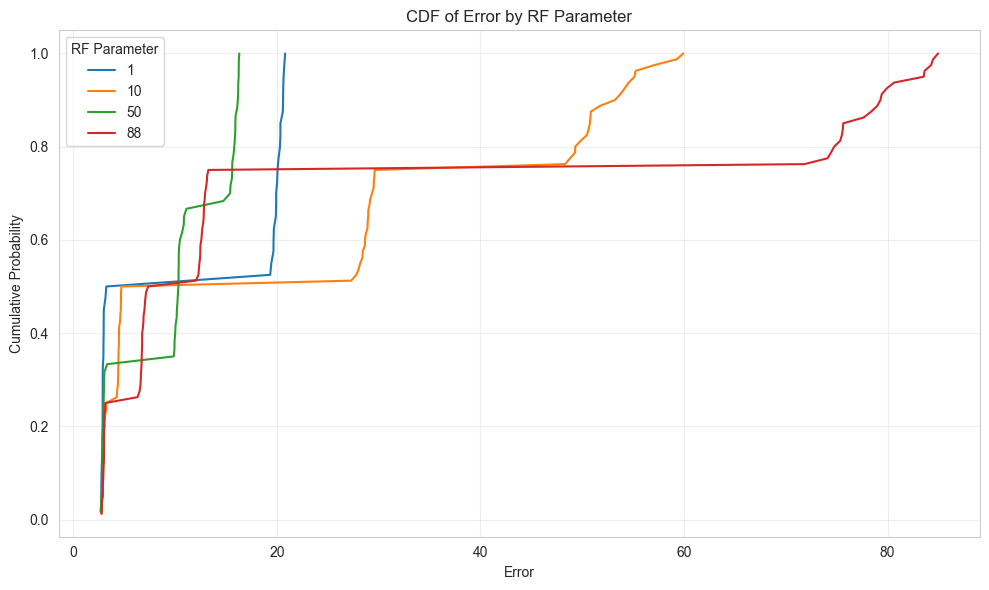

In [43]:
from scripts.utils import *

config = get_config("frequency_map.json")

config

for k, v in config.items():
    print(k)
    print(v.values())


1
dict_values([3731])
10
dict_values([2160, 3649, 3649, 2160, 2160, 780])
50
dict_values([763, 763, 3624, 3624])
88
dict_values([1844, 3570, 3570, 2675])


In [31]:

import matplotlib.patches as mpatches
from scripts.plotting import *


def make_boxplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "forestgreen",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a boxplot of the given dataframe.

    :param baseline:
    :param df:
    :param title:
    :param x_label:
    :param y_label:
    :param color: Color of the boxes
    """
    data_values = [df[col] for col in df.columns]
    means = [df[col].mean() for col in df.columns]
    num_boxes = len(df.columns)

    plt.figure(figsize=(20, 14))
    median_props = dict(color="black", linewidth="3")
    plot = plt.boxplot(
        data_values,
        patch_artist=True,
        tick_labels=df.columns,
        medianprops=median_props,
    )

    # Handle color assignment
    if isinstance(color, dict):
        for patch, col_name in zip(plot["boxes"], df.columns):
            patch.set_facecolor(color.get(col_name.strip('*'), "forestgreen"))
    else:
        for patch in plot["boxes"]:
            patch.set_facecolor(color)

    for patch, col_name in zip(plot["boxes"], df.columns):
        if col_name[-1] == '*':
            patch.set_hatch('o')
        else:
            patch.set_hatch('/')

    legend_elements = []

    # Add boxes to legend
    for col_name in df.columns:
        hatch = 'o' if col_name[-1] == '*' else '/'
        box_color = color.get(col_name.strip('*'), "forestgreen") if isinstance(color, dict) else color

        label = f'{col_name[:-1]} MHz (best beam)' if col_name[-1] == '*' else f'{col_name} MHz'
        label = f'All frequencies {label.split("all MHz")[1]}' if label.startswith('all MHz') else label
        patch = mpatches.Patch(
            facecolor=box_color,
            hatch=hatch,
            label=label
        )
        legend_elements.append(patch)

    if baseline:
        plt.axhline(
            y=baseline,
            color="red",
            linestyle="-",
            linewidth=2,
            label="Baseline",
        )
        plt.legend(loc="upper right")

    if annotate:
        text_offset = 0.4 if num_boxes < 4 else 0.5

        for i, mean in enumerate(means, 1):
            plt.text(
                i + text_offset,
                mean,
                f"\n{mean:.2f}",
                horizontalalignment="right",
                verticalalignment="center",
                color="black",
            )

    # formatting the plot
    plt.title(title)
    plt.grid(axis="y")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(handles=legend_elements, loc='upper right')
    plt.margins(y=0.2)

    # Show the plot
    plt.show()




In [32]:

from matplotlib.lines import Line2D


def make_barplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "skyblue",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a bar plot of the given dataframe.
    """
    if df.empty:
        raise ValueError("The DataFrame is empty.")

    means = df.mean()

    plt.figure(figsize=(20, 12))

    # Handle color assignment
    if isinstance(color, dict):
        colors = [color.get(col.strip('*'), "forestgreen") for col in means.index]
        hatches = ['o' if col[-1] == '*' else '/' for col in means.index]
        bars = plt.bar(
            range(len(means)), means.values, color=colors, tick_label=means.index, hatch=hatches,
        )
    else:
        bars = plt.bar(
            range(len(means)), means.values, color=color, tick_label=means.index
        )

    # Create legend elements
    legend_elements = []

    # Add bars to legend
    for col_name in means.index:
        bar_color = color.get(col_name.strip('*'), "forestgreen") if isinstance(color, dict) else color
        hatch = 'o' if col_name[-1] == '*' else '/'
        label = f'{col_name[:-1]} MHz (best beam)' if col_name[-1] == '*' else f'{col_name} MHz'
        label = f'All frequencies {label.split("all MHz")[1]}' if label.startswith('all MHz') else label

        patch = mpatches.Patch(
            facecolor=bar_color,
            label=label,
            hatch=hatch,
        )
        legend_elements.append(patch)

    # Add baseline to legend if it exists
    if baseline is not None:
        legend_elements.append(Line2D([0], [0], color='red', linestyle='-', linewidth=2, label='Baseline'))

    # Add the legend
    plt.legend(handles=legend_elements, loc='upper left', ncol=2)

    if annotate:
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
            )

    # Formatting the plot
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    def thousands_formatter(x, pos):
        return f"{x / 1000:.0f}k"

    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
    plt.tight_layout()
    plt.grid(axis="y")
    plt.margins(y=0.8)
    plt.yscale('log')

    # Show the plot
    plt.show()


Index(['2160', '3649', '780', 'all', '3731', 'all'], dtype='object')


ValueError: X must have 2 or fewer dimensions

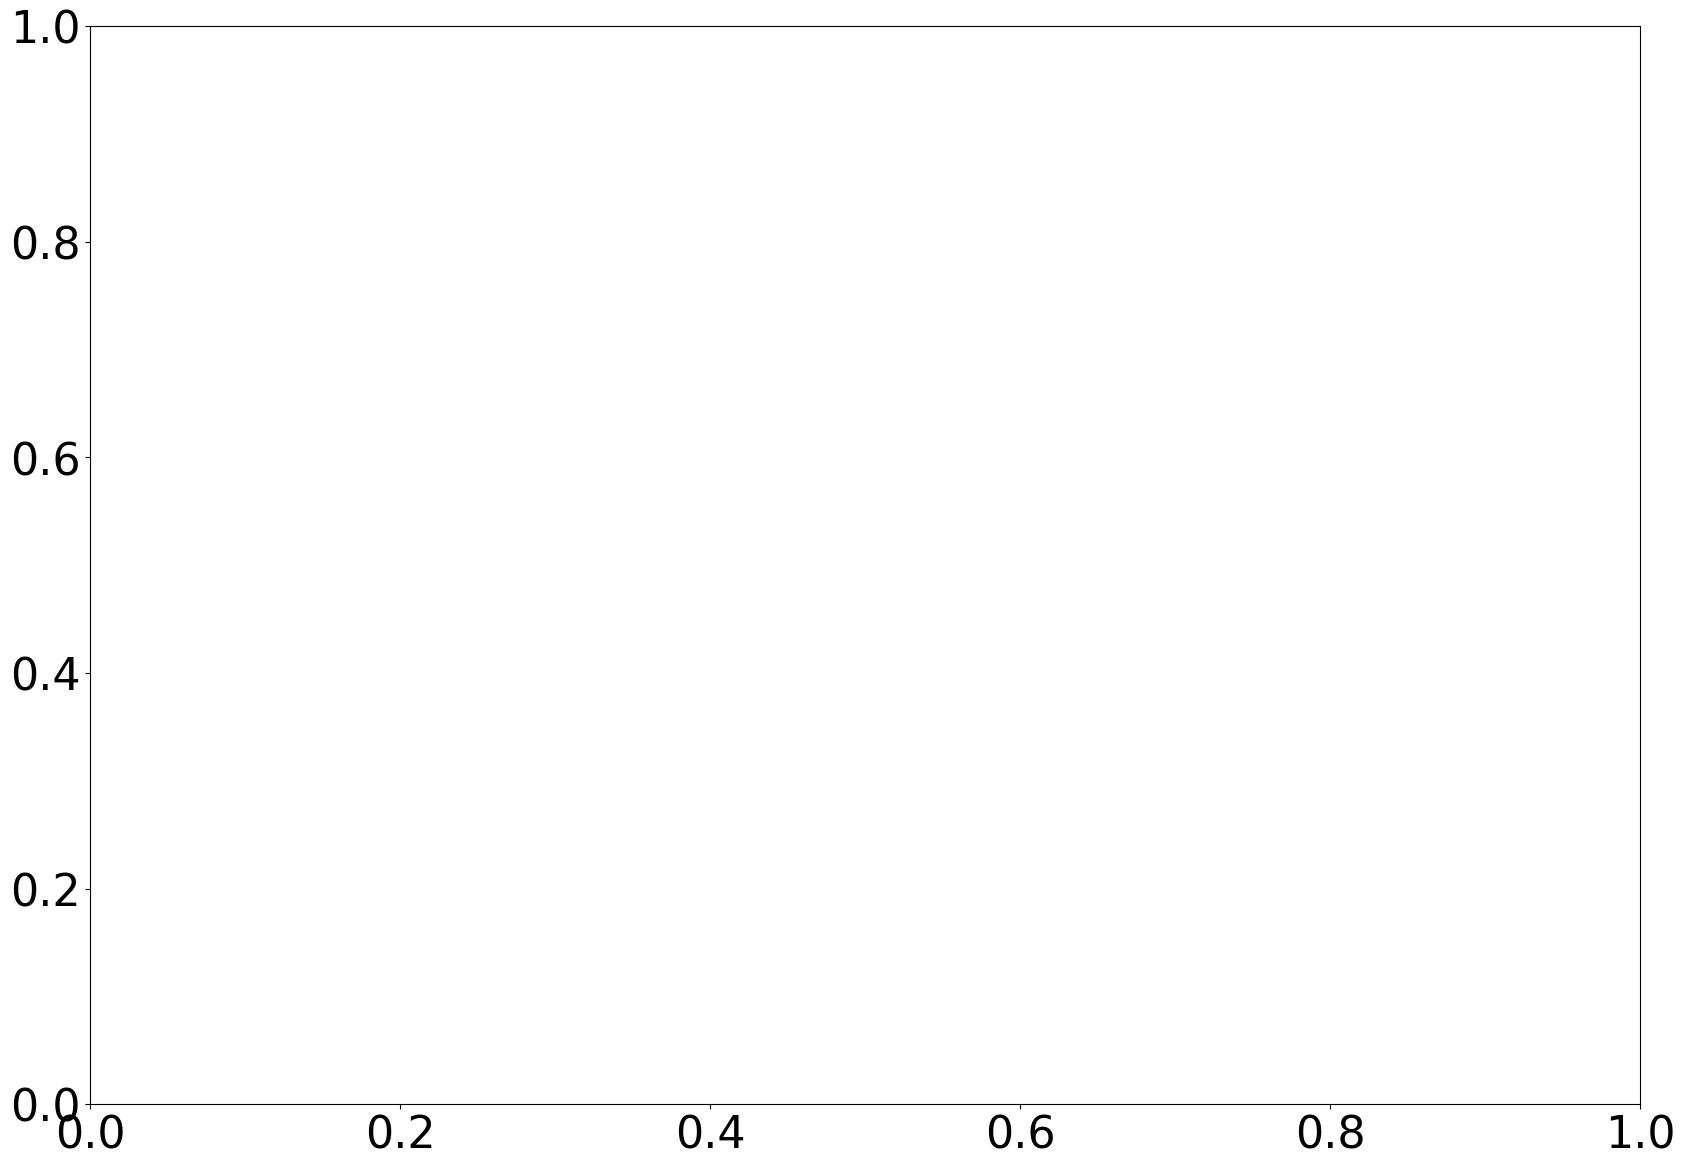

In [42]:
color_map = get_config("color_map.json", "frequency")

column_orders = [
    ['780', '2160', '3649', '3731', 'all'],
]

star_order = list(map(lambda x: x + "*", order))
all_cols = ['780*', '2160', '3649', '3731', 'all']

all_errors = pd.concat([errors_df, errors_df_tim], axis=1)
all_entries = pd.concat([entries_df, entries_df_tim], axis=1)

print(all_errors.columns)
#
make_boxplot(
    df=all_errors,
    title=f'Min average error: {title_string}',
    x_label='Frequency (MHz)',
    y_label='Error (m)',
    color=color_map,
    annotate=True,
)

# make_barplot(
#     df=all_entries,
#     title=f'Number of data points: {title_string}',
#     x_label='Frequency (MHz)',
#     y_label='Number of entries (log)',
#     color=color_map,
#     annotate=True,
# )

all_entries

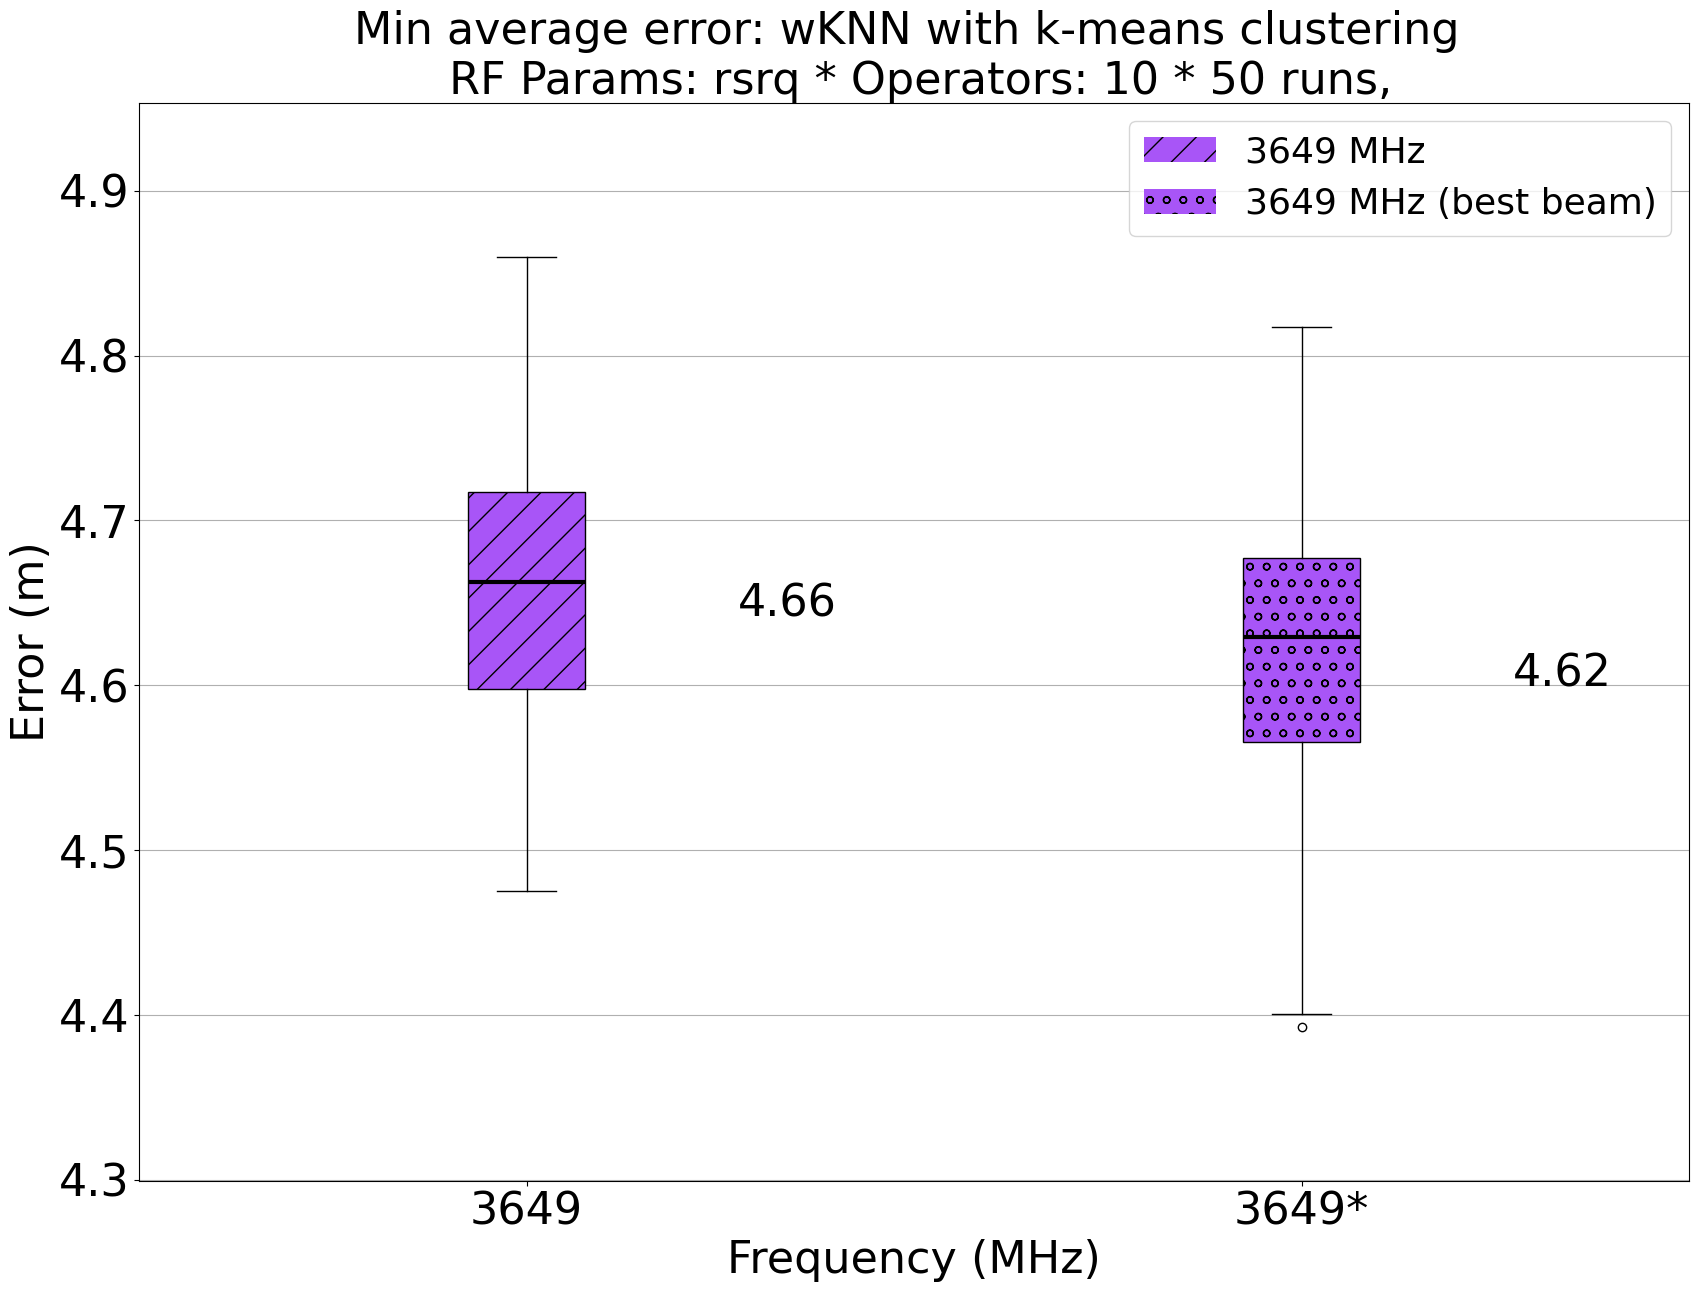

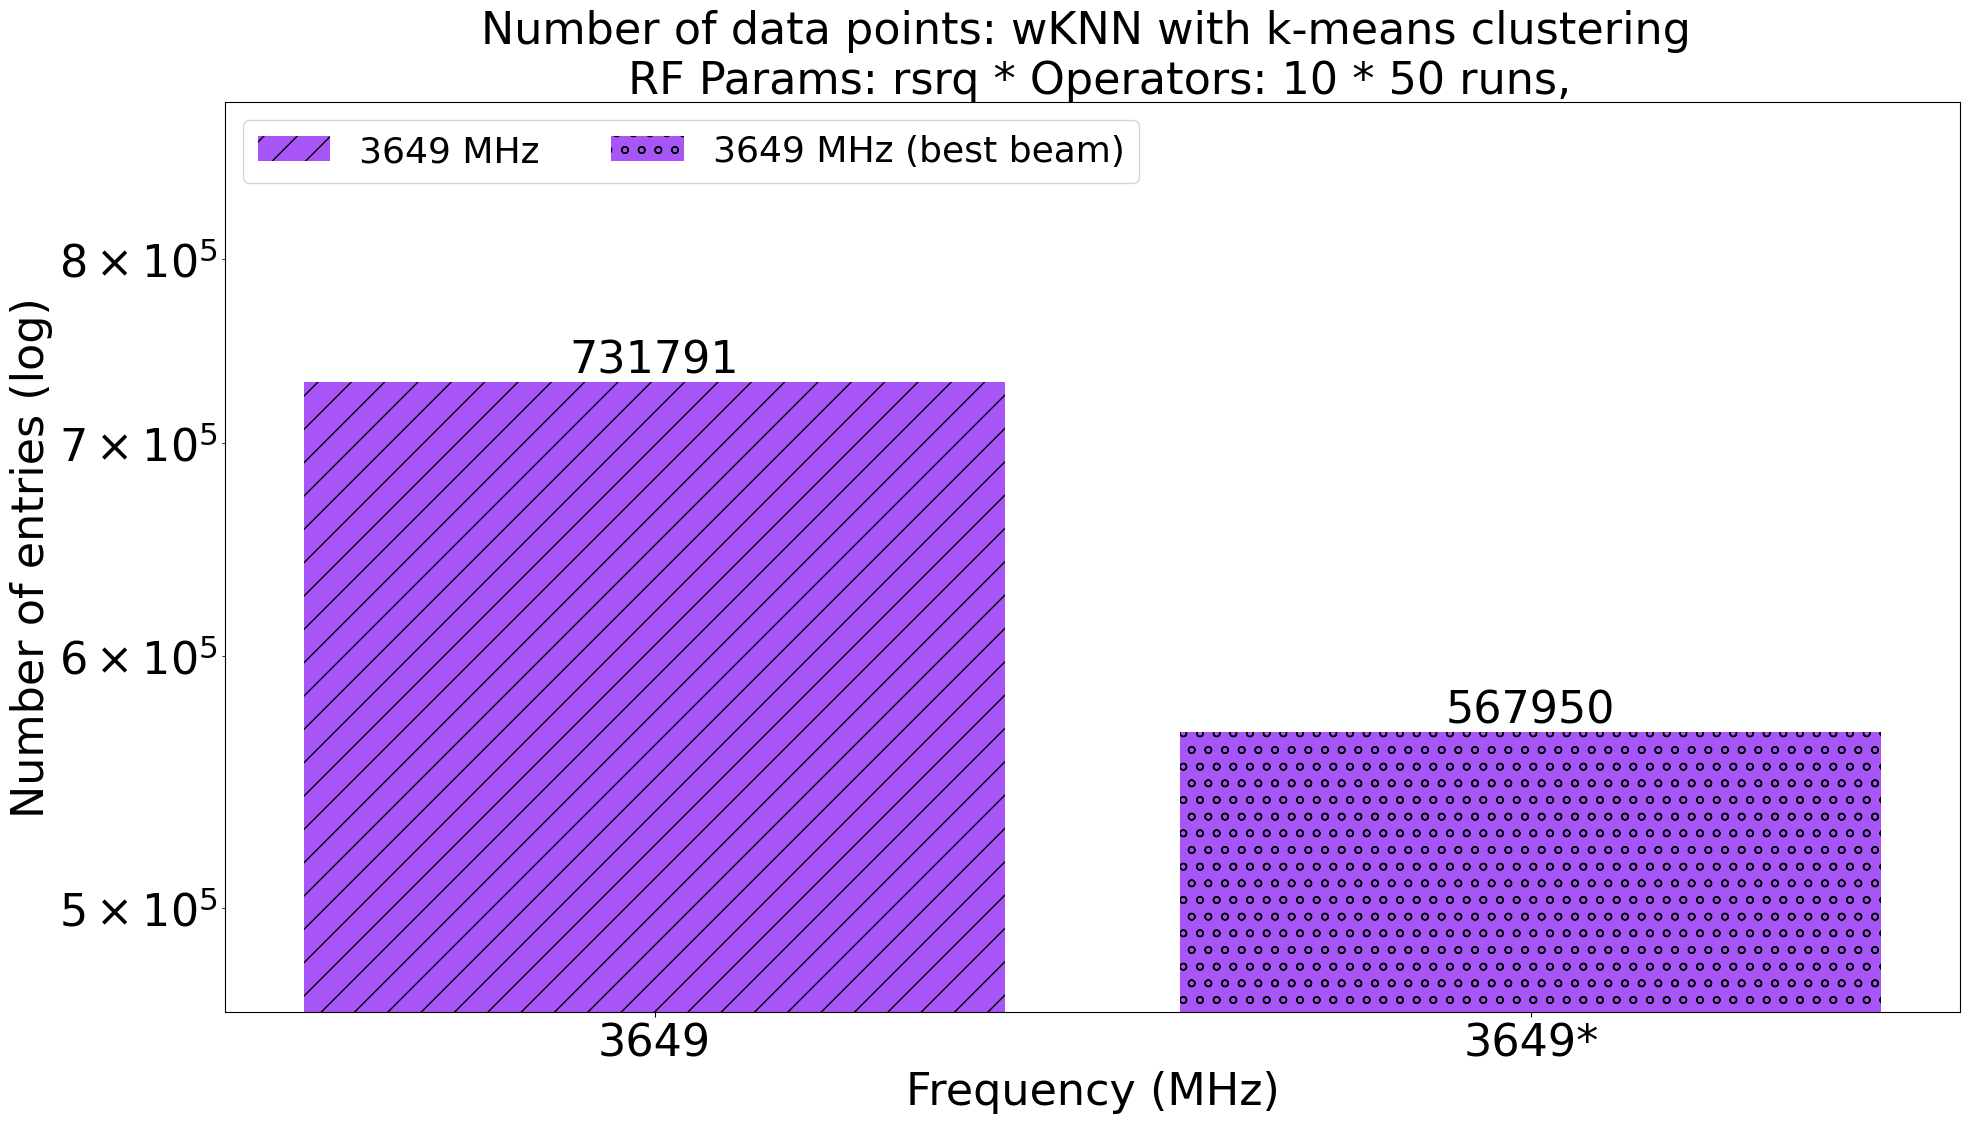

In [15]:
# all_cols = merge_alternate(order, star_order)
#
# print(all_cols)
#
display_cols = ['3649', '3649*', ]

all_errors = pd.concat([errors_df, errors_df_control], axis=1)[display_cols]
all_entries = pd.concat([entries_df, entries_df_control], axis=1)[display_cols]

make_boxplot(
    df=all_errors,
    title=f'Min average error: {title_string}',
    x_label='Frequency (MHz)',
    y_label='Error (m)',
    color=color_map,
    annotate=True,
)

make_barplot(
    df=all_entries,
    title=f'Number of data points: {title_string}',
    x_label='Frequency (MHz)',
    y_label='Number of entries (log)',
    color=color_map,
    annotate=True,
)